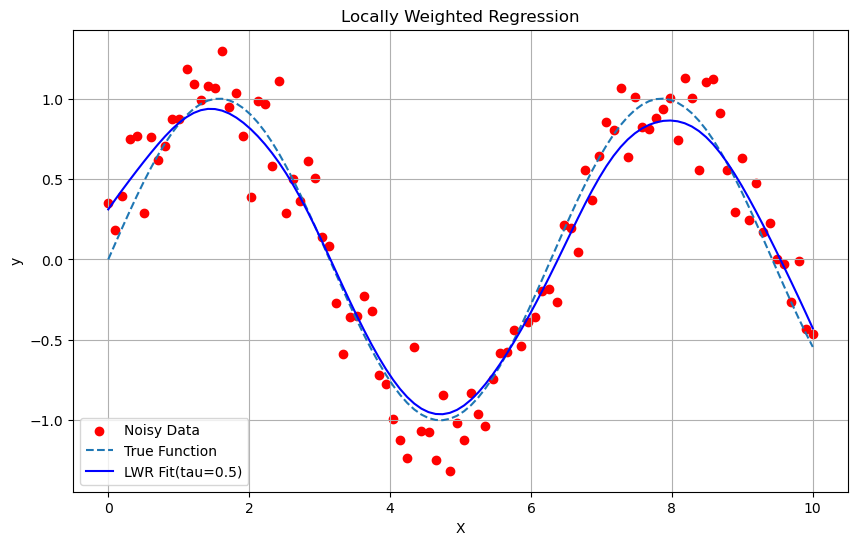

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
X = np.linspace(0, 10, 100)
y = np.sin(X) + np.random.normal(scale=0.2, size=X.shape)

# Add bias term
def add_bias(X):
    return np.c_[np.ones(X.shape[0]), X]

# Locally weighted regression function
def locally_weighted_regression(x_query, X_train, y_train, tau):
    m = X_train.shape[0]
    w = np.eye(m)
    for i in range(m):
        diff = x_query - X_train[i]
        w[i, i] = np.exp(-(diff**2) / (2 * tau**2))
    X_bias = add_bias(X_train)
    theta = np.linalg.pinv(X_bias.T @ w @ X_bias) @ X_bias.T @ w @ y_train
    return np.array([1, x_query]) @ theta

tau = 0.5
y_pred = np.array([locally_weighted_regression(x, X, y, tau) for x in X])

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', label='Noisy Data')
plt.plot(X, np.sin(X), label='True Function', linestyle='dashed')
plt.plot(X, y_pred, color='blue', label=f'LWR Fit(tau={tau})')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Locally Weighted Regression')
plt.legend()
plt.grid(True)
plt.show()